In [1]:
# jax ecosystem
import jax

jax.config.update("jax_enable_x64", True)
# jax.config.update("jax_platform_name", "gpu")
print(jax.local_devices()[0].device_kind)

import jax.numpy as np
import jax.tree as jtu
import jax.random as jr

# amigo
import amigo


# matplotlib ecosystem
import matplotlib.pyplot as plt
import matplotlib as mpl
import ehtplot
import scienceplots

# other
import pandas as pd
import os

# matplotlib parameters
plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 300
plt.rcParams["font.size"] = 8
plt.rcParams["xtick.direction"] = "out"
plt.rcParams["ytick.direction"] = "out"

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]

inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)

cpu


# Loading in data

In [2]:
# Setting data path
from socket import gethostname

print(gethostname())

if (
    gethostname() == "maxs-mbp-14.shared.sydney.edu.au"
    or gethostname() == "Maxs-MacBook-Pro-14.local"
):
    data_dir = "/Volumes/morgana2/snert/max/data/JWST/"
    cache_dir = "/Volumes/morgana2/snert/max/data/amigo_cache"
    badpix_dir = "/Users/mc/code/amigo/src/amigo/data/badpix.npy"
    amigo_files_path = "/Volumes/morgana2/snert/max/data/amigo_files/v_0.0.10"
    output_path = "/Users/mc/code/dorito_notebooks/files/outputs/retrain"

else:
    data_dir = "/fred/oz440/max/data/JWST/"
    cache_dir = "/fred/oz440/max/data/amigo_cache"
    badpix_dir = "/fred/oz440/max/code/amigo/src/amigo/data/badpix.npy"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.10"
    output_path = "/fred/oz440/max/outputs/retrain"

# dealing with saving figures when running in script
save_flag = True if get_ipython() is not None else False
if save_flag:
    job_id = os.environ.get("SLURM_ARRAY_JOB_ID")
    if job_id == None:
        job_id = "local"
    save_path = os.path.join(output_path, job_id)
    if not os.path.exists(save_path):
        os.makedirs(save_path)
    print(f"Save path: {save_path}")
else:
    save_path = None

maxs-mbp-14.shared.sydney.edu.au
Save path: /Users/mc/code/dorito_notebooks/files/outputs/retrain/local


In [3]:
# Add extra bad pixels
def add_badpix(file):
    file["BADPIX"].data[:1, :] = 1
    file["BADPIX"].data[-1:, :] = 1
    file["BADPIX"].data[:, :1] = 1
    file["BADPIX"].data[:, -1:] = 1
    file["BADPIX"].data[41:43, 1] = 1
    file["BADPIX"].data[58, 67] = 1
    file["BADPIX"].data[43, 0] = 1
    file["BADPIX"].data[44, 70] = 1
    file["BADPIX"].data[4, 45] = 1
    file["BADPIX"].data[58, 14] = 1
    file["BADPIX"].data[61, 54] = 1
    file["BADPIX"].data[51, 27] = 1
    file["badpix"].data[29, 69] = 1
    file["badpix"].data[49, 74] = 1
    file["badpix"].data[61, 52] = 1
    file["badpix"].data[53, 18] = 1
    return file


# Visualising metadata in a table
def summarise_files(files):
    prog_ids = []
    fnames = []
    targets = []
    filts = []
    diths = []
    ngroups = []
    time = []
    pis = []
    cals = []

    for file in files:
        header = file[0].header

        prog_ids.append(header["PROGRAM"][1:])
        fnames.append(header["FILENAME"][:25])
        targets.append(header["TARGPROP"])
        filts.append(header["FILTER"])
        diths.append(f"{header["PATT_NUM"]}/{header["NUMDTHPT"]}")
        ngroups.append(f"{header["NGROUPS"]}/{header["NINTS"]}")
        time.append(header["DATE-BEG"])
        pis.append(header["PI_NAME"])
        try:
            cals.append(header["IS_PSF"])
        except KeyError:
            cals.append("FLAT")

    df = pd.DataFrame(
        {
            "program": prog_ids,
            # "filename": fnames,
            "target": targets,
            "filter": filts,
            "dither": diths,
            "g/i": ngroups,
            "date": time,
            "PI": pis,
            "CAL": cals,
        }
    )
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values("date").reset_index(drop=True)
    df = df.assign(date=pd.to_datetime(df["date"]).dt.strftime("%d-%m-%Y"))

    with pd.option_context(
        "display.expand_frame_repr",
        False,
        "display.max_columns",
        None,
        "display.max_rows",
        None,
        "display.width",
        1000,
    ):
        print(df)

    # df.to_excel("cal_data.xlsx", index=False)

## Validation files
Calibrators from other science programs

In [4]:
# LOADING IN DATA
from astropy.io import fits
from amigo.files import get_files

val_files = []


# 1093, Deepashri Thatte
program_path = os.path.join(data_dir, "1093/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
files = [f for f in files if f[0].header["TARGPROP"] == "HD-36805"]
val_files += files

# 1843, Jens Kammerer
program_path = os.path.join(data_dir, "1843/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
val_files += files

# 1242, Doug Johnstone
program_path = os.path.join(data_dir, "1242/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
files = [f for f in files if f[0].header["TARGPROP"] != "TD-CAL-HD-101531"]
val_files += files

val_files = [add_badpix(file) for file in val_files]
summarise_files(val_files)

   program            target filter dither     g/i        date                 PI   CAL
0     1093          HD-36805  F480M    1/2    9/65  23-05-2022  Thatte, Deepashri  True
1     1093          HD-36805  F480M    2/2    9/65  23-05-2022  Thatte, Deepashri  True
2     1093          HD-36805  F430M    1/2    6/82  23-05-2022  Thatte, Deepashri  True
3     1093          HD-36805  F430M    2/2    6/82  23-05-2022  Thatte, Deepashri  True
4     1093          HD-36805  F380M    1/2   3/122  23-05-2022  Thatte, Deepashri  True
5     1093          HD-36805  F380M    2/2   3/122  23-05-2022  Thatte, Deepashri  True
6     1093          HD-36805  F480M   1/25    9/65  23-05-2022  Thatte, Deepashri  True
7     1093          HD-36805  F480M   2/25    9/65  23-05-2022  Thatte, Deepashri  True
8     1093          HD-36805  F480M   3/25    9/65  23-05-2022  Thatte, Deepashri  True
9     1093          HD-36805  F480M   4/25    9/65  23-05-2022  Thatte, Deepashri  True
10    1093          HD-36805  F4

## Calibration files
The main training data, including flats.

In [5]:
cal_files = []

print("CAL4481 - Anand Sivaramakrishnan")
program_path = os.path.join(data_dir, "4481/calslope/")
files = get_files(program_path, "nis_calslope", IS_PSF=True)
cal_files += files

# print()
# print("CAL8330 - Benjamin Pope")
# program_path = os.path.join(data_dir, "8330/calslope/")
# files = get_files(program_path, "nis_calslope")
# cal_files += files

cal_files = [add_badpix(file) for file in cal_files]
summarise_files(cal_files)

CAL4481 - Anand Sivaramakrishnan
   program    target filter dither      g/i        date                       PI   CAL
0     4481  HD-41094  F480M    1/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
1     4481  HD-41094  F480M    2/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
2     4481  HD-41094  F480M    3/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
3     4481  HD-41094  F480M    4/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
4     4481  HD-41094  F480M    5/5   30/760  05-05-2024  Sivaramakrishnan, Anand  True
5     4481  HD-41094  F380M    1/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
6     4481  HD-41094  F380M    2/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
7     4481  HD-41094  F380M    3/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
8     4481  HD-41094  F380M    4/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
9     4481  HD-41094  F380M    5/5  11/1060  05-05-2024  Sivaramakrishnan, Anand  True
10    4481

Flats.

In [6]:
flat_files = []
print()
print("FLATS")
program_path = os.path.join(data_dir, "FLATS/calslope/")
files = get_files(program_path, "nis_calslope", EXP_TYPE="NIS_LAMP")
flat_files += files

flat_files = [
    add_badpix(file) for file in flat_files if file[0].header["NGROUPS"] != 45  # Louis
]
summarise_files(flat_files)


FLATS
  program   target filter dither    g/i        date             PI   CAL
0    1503  UNKNOWN  F380M    1/1  30/10  04-02-2023  Martel, Andre  FLAT
1    1503  UNKNOWN  CLEAR    1/1  25/11  10-02-2023  Martel, Andre  FLAT
2    1503  UNKNOWN  CLEAR    1/1  20/33  10-02-2023  Martel, Andre  FLAT
3    1503  UNKNOWN  F480M    1/1  30/10  16-03-2023  Martel, Andre  FLAT
4    4472  UNKNOWN  F277W    1/1  20/10  28-10-2023  Martel, Andre  FLAT
5    4472  UNKNOWN  F356W    1/1  20/10  29-04-2024  Martel, Andre  FLAT
6    6654  UNKNOWN  CLEAR    1/1  10/11  22-07-2024  Martel, Andre  FLAT
7    6654  UNKNOWN  F430M    1/1  30/10  27-07-2024  Martel, Andre  FLAT
8    6654  UNKNOWN  F444W    1/1  20/10  29-10-2024  Martel, Andre  FLAT


# Exposures

Some bad pixel stuff.

In [7]:
base_badpix = np.load(badpix_dir)

flat_badpix = np.zeros((80, 80))
for file in flat_files:
    flat_badpix = np.array(file["BADPIX"].data)
    flat_badpix += flat_badpix.astype(int)
flat_badpix = ~(flat_badpix == 0)
full_badpix = flat_badpix | base_badpix


def add_badpix_again(file):
    badpix = np.array(file["BADPIX"].data, dtype=bool)
    file["BADPIX"].data = (badpix | full_badpix).astype(int)
    return file


fig, ax = plt.subplots(1, 3, figsize=(8, 3))
ax[0].imshow(base_badpix, cmap="grey_r")
ax[0].set_title("Base badpix")
ax[1].imshow(flat_badpix, cmap="grey_r")
ax[1].set_title("Flat badpix")
ax[2].imshow(full_badpix, cmap="grey_r")
ax[2].set_title("Full badpix")
plt.tight_layout()

if save_flag:
    plt.savefig(os.path.join(save_path, "badpix.png"), dpi=200)
    plt.close()
else:
    plt.show()

In [8]:
from amigo.model_fits import PointFit, FlatFit

# Construct the exposures
flat_exposures = [FlatFit(add_badpix_again(file)) for file in flat_files]
cal_exposures = [PointFit(add_badpix_again(file)) for file in cal_files]
val_exposures = [PointFit(add_badpix_again(file)) for file in val_files]
exposures = cal_exposures + flat_exposures + val_exposures

# just closing the files
files = cal_files + val_files + flat_files
_ = [f.close() for f in files]

Finally, let's batch the exposures for training.

In [9]:
from amigo.fitting import batch_exposures

# Get the batches: Calibrator, flats, and validators
cal_batch = batch_exposures(cal_exposures, batch_size=3, key="cal")
flat_batch = batch_exposures(flat_exposures, batch_size=3, key="flat")
val_batch = batch_exposures(val_exposures, batch_size=3, key="val")
batches = {**cal_batch, **flat_batch}

# Building model

In [10]:
from amigo.core_models import AmigoModel
from amigo.optical_models import AMIOptics
from amigo.detector_models import LinearDetector
from amigo.ramp_models import NonLinearRamp
from amigo.read_models import ReadModel

# Get the model
model = AmigoModel(
    exposures=exposures,
    optics=AMIOptics(static=False),
    detector=LinearDetector(),
    ramp_model=NonLinearRamp(),
    read=ReadModel(),
)

W0326 16:41:30.543500 3473753 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


Populate from state.

In [11]:
state = np.load(f"{amigo_files_path}/calibration.npy", allow_pickle=True).item()
print(state.keys())

for key, value in state.items():
    if key in ["positions", "fluxes", "aberrations", "nn_weights"]:
        continue
    if key in ["transmission", "badpix"]:
        continue
    model = model.set(key, value)

ab_dict = {}
for key, _ in model.aberrations.items():
    prog, filt = key.split("_")
    ab_dict[key] = state["aberrations"][filt]

model = model.set("aberrations", ab_dict)

dict_keys(['FF', 'SRF', 'non_linearity', 'jitter', 'dark_current', 'defocus', 'nn_weights', 'aberrations', 'transmission', 'badpix'])


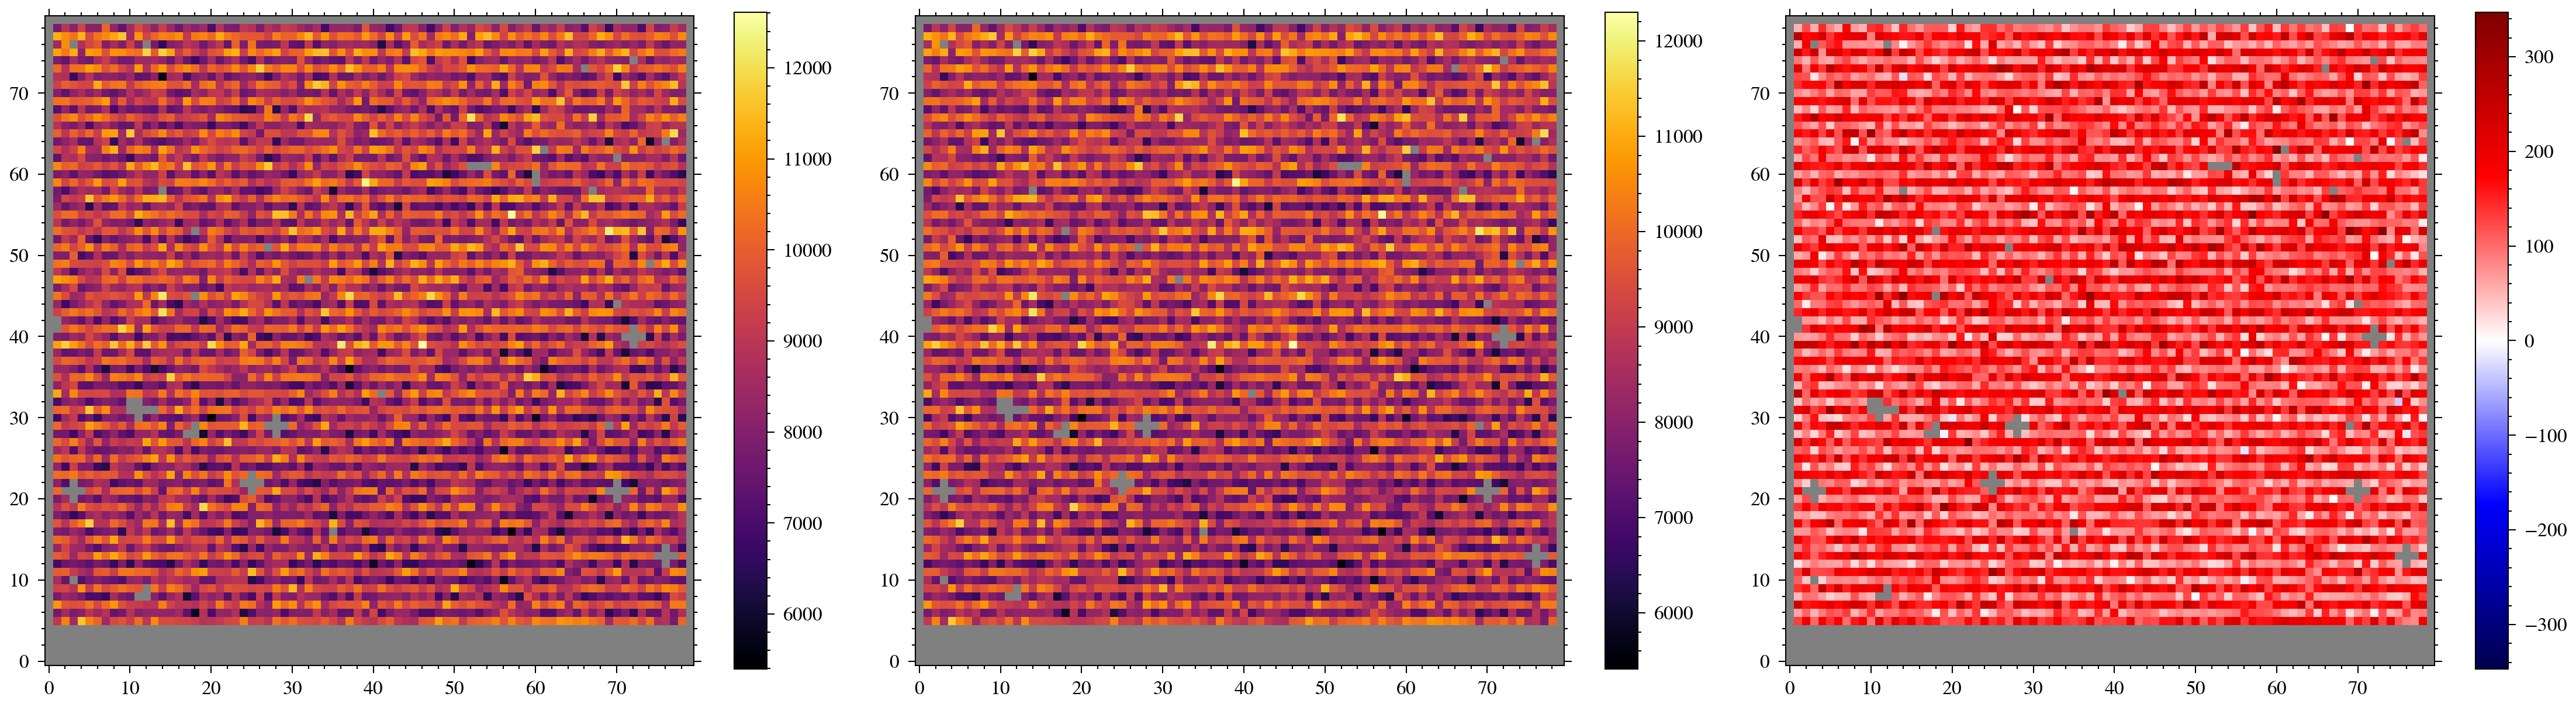

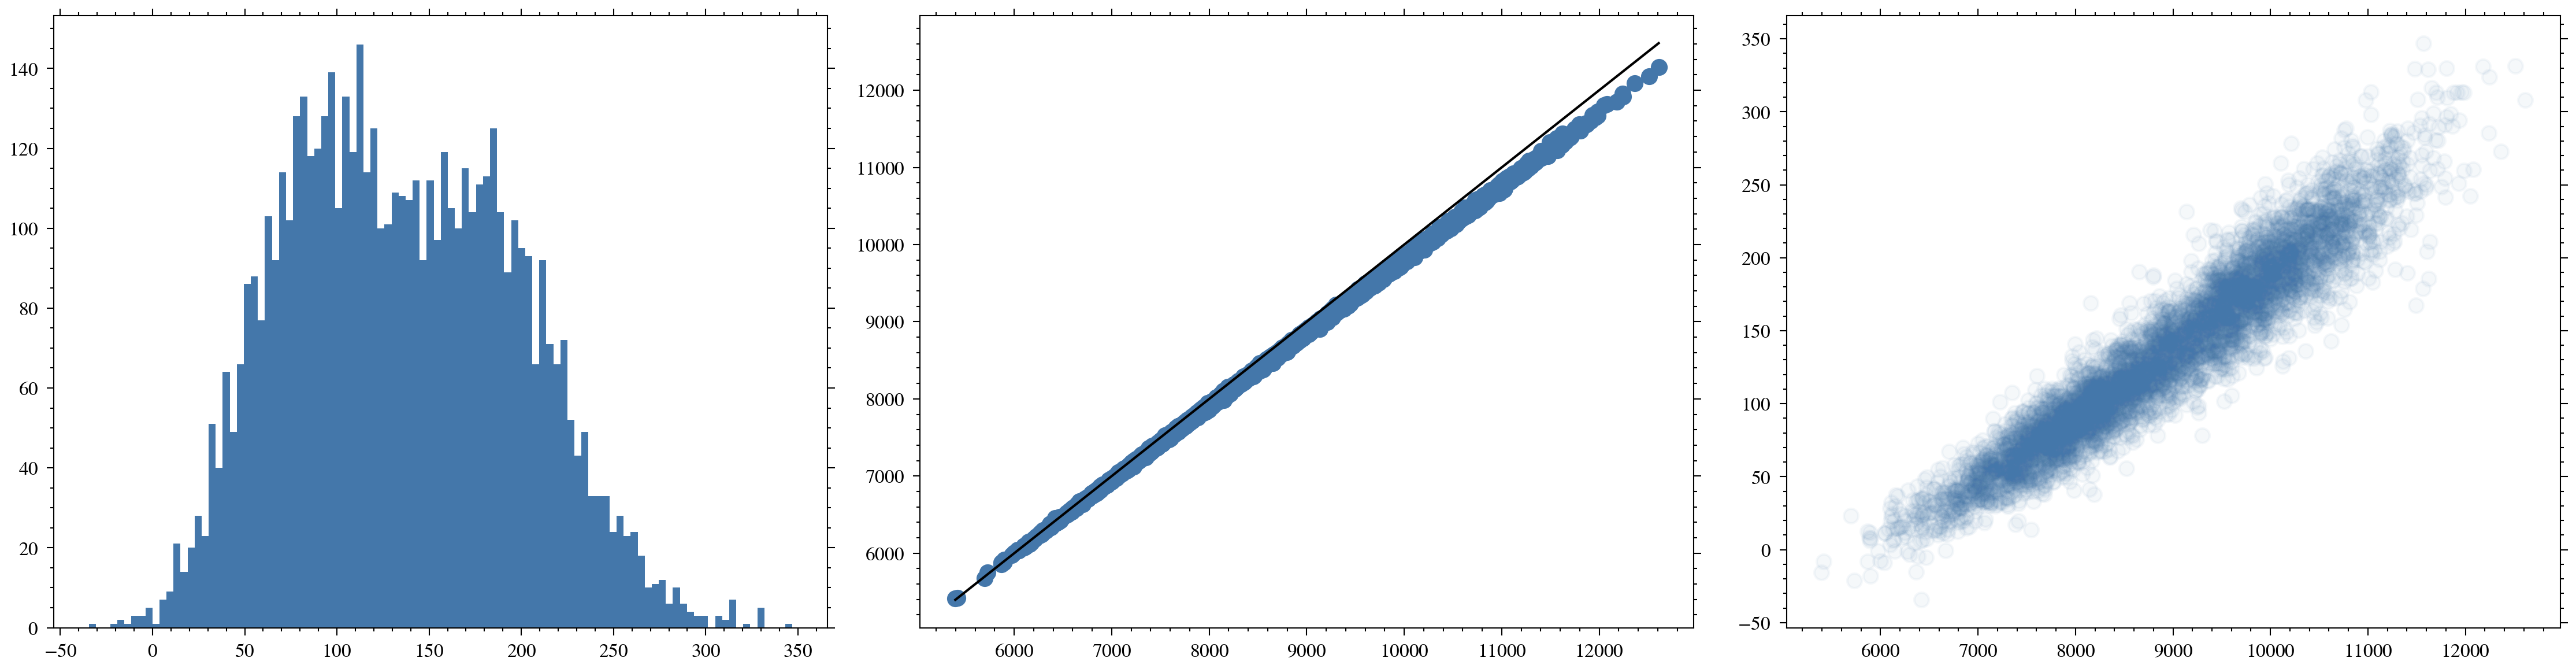

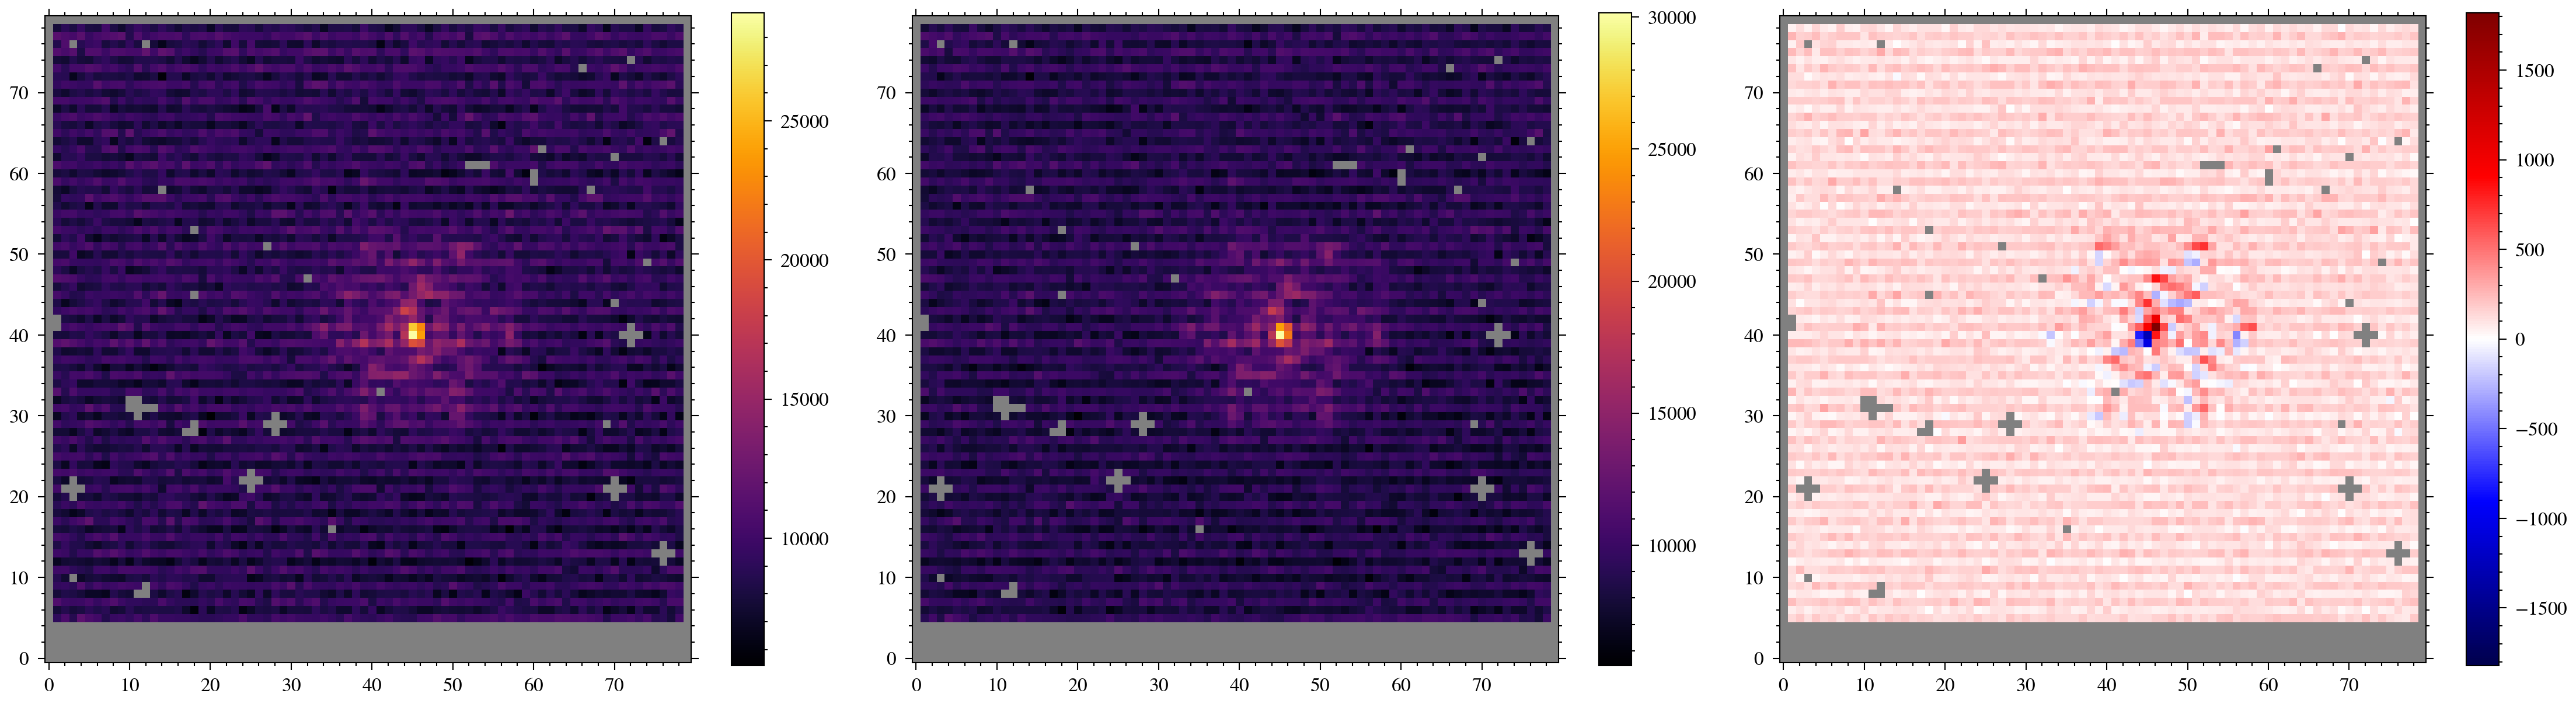

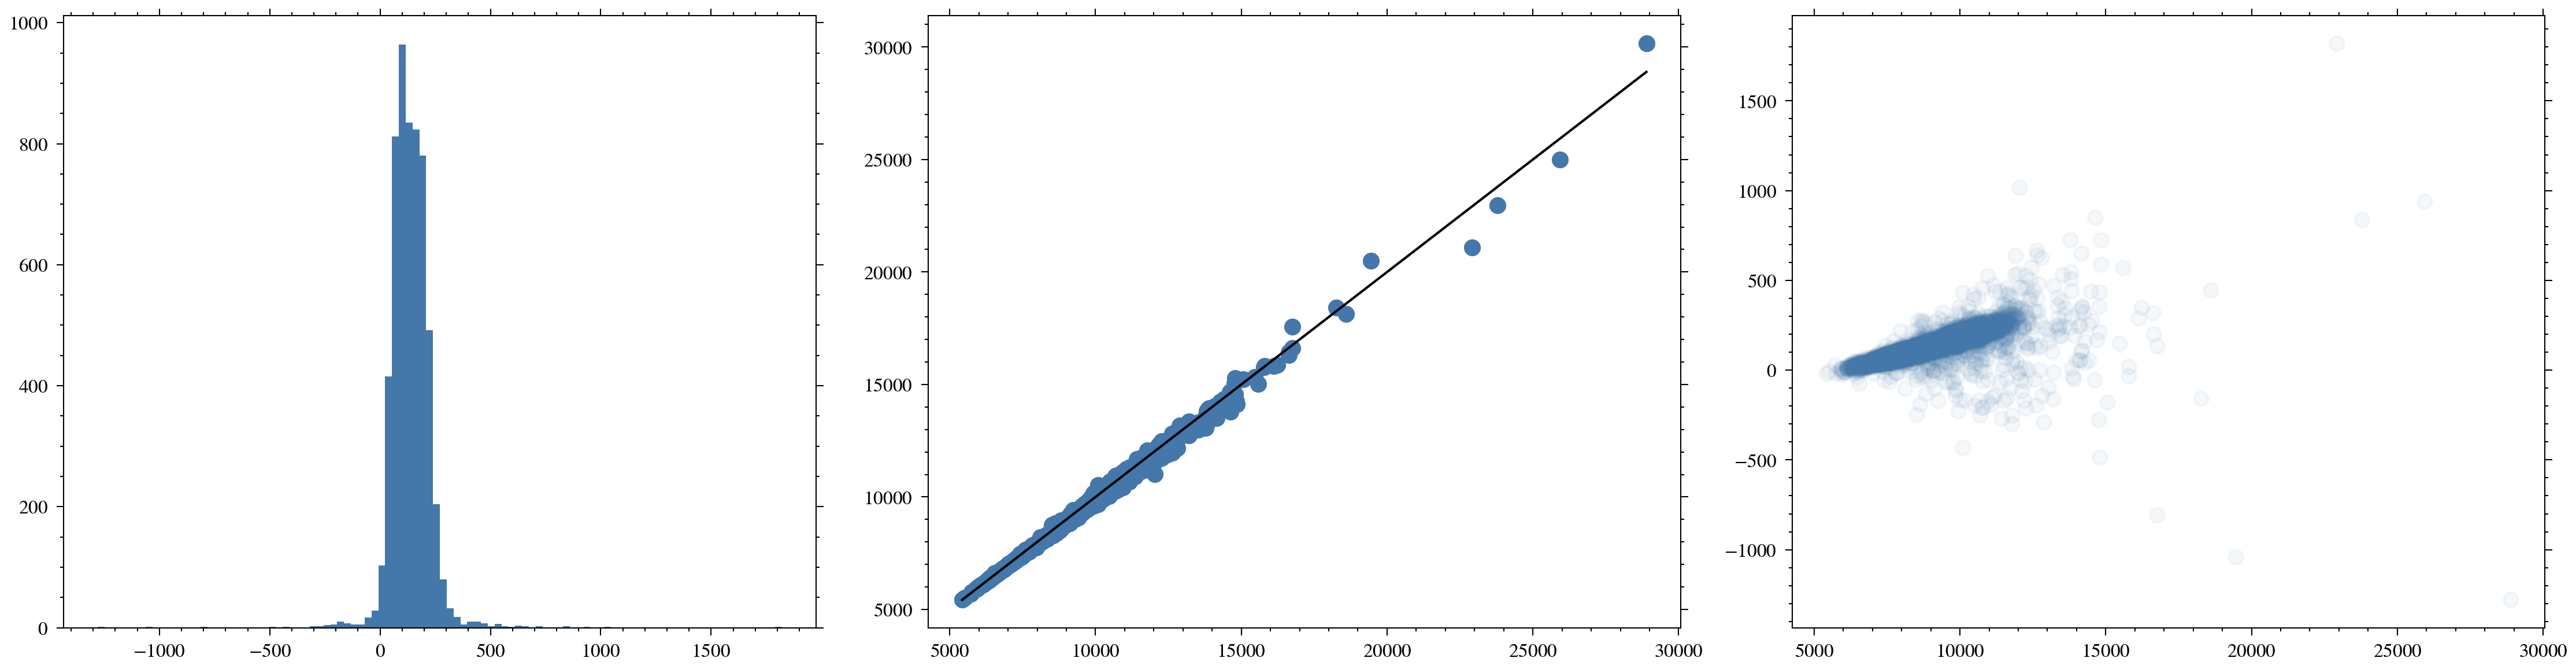

In [12]:
for exp in cal_exposures:

    for i in [0, -1]:
        # for i in [0]:

        badpix = exp.badpix
        data = np.where(badpix, np.nan, exp.ramp[i])
        ramp = np.where(badpix, np.nan, exp(model, return_slopes=False)[i])
        res = data - ramp
        v = np.nanmax(np.abs(res))

        plt.figure(figsize=(15, 4))
        plt.subplot(1, 3, 1)
        plt.imshow(data, inferno)
        plt.colorbar()

        plt.subplot(1, 3, 2)
        plt.imshow(ramp, inferno)
        plt.colorbar()

        plt.subplot(1, 3, 3)
        plt.imshow(res, seismic, vmin=-v, vmax=v)
        plt.colorbar()

        plt.tight_layout()
        plt.show()

        plt.figure(figsize=(15, 4))
        plt.subplot(1, 3, 1)
        plt.hist(res.flatten(), bins=100)

        plt.subplot(1, 3, 2)
        plt.scatter(data, ramp)
        xs = np.linspace(np.nanmin(data), np.nanmax(data), 1000)
        plt.plot(xs, xs, c="k")

        plt.subplot(1, 3, 3)
        plt.scatter(data, res, alpha=0.05)

        plt.tight_layout()
        plt.show()
    break

## Checking initial fits
Just looking at one per filter. Starting with the calibrator exposures.

In [13]:
from amigo.plotting import summarise_fit

done = []
for exp in cal_exposures:
    if exp.filter in done:
        continue
    print(exp.filter)
    summarise_fit(model, exp, save_path=save_path)
    done.append(exp.filter)

F430M
F480M
F380M


Now the validator exposures.

In [14]:
from amigo.plotting import summarise_fit

done = []
for exp in val_exposures:
    if exp.filter in done:
        continue
    print(exp.program, exp.filter, exp.star, exp.ngroups, exp.nints)
    summarise_fit(model, exp, save_path=save_path)
    done.append(exp.filter)

01093 F480M HD-36805 9 65
01093 F430M HD-36805 6 82
01093 F380M HD-36805 3 122


Finally, the flats.

In [15]:
from amigo.plotting import summarise_fit

for exp in flat_exposures:
    print(exp.program, exp.filter, exp.star, exp.ngroups, exp.nints)
    summarise_fit(model, exp, save_path=save_path)

FLAT CLEAR NIS_LAMP 10 11
FLAT CLEAR NIS_LAMP 20 33
FLAT F277W NIS_LAMP 20 10
FLAT F356W NIS_LAMP 20 10
FLAT F444W NIS_LAMP 20 10
FLAT CLEAR NIS_LAMP 25 11
FLAT F380M NIS_LAMP 30 10
FLAT F430M NIS_LAMP 30 10
FLAT F480M NIS_LAMP 30 10


# Optimisation

## Setup
For the neural network training we want to use a custom learning rate warmup and a temperature decay, so we will have to modify a lot of the statistical functions of amigo to be able to handle this

In [16]:
def norm_fn(model_params, args):
    """
    Normalisation function.
    """
    if hasattr(model_params, "FF"):
        FF = model_params.FF
        FF -= np.median(FF) - 1.0
        FF = FF.at[badpix].set(1.0)
        model_params = model_params.set("FF", FF)

    if hasattr(model_params, "non_linearity"):
        non_lin = model_params.non_linearity.at[:, badpix].set(0)
        model_params = model_params.set("non_linearity", non_lin)

    return model_params, args


def posterior(model, exposure, l2_norm=0.0, ff_std=0.035, nl_std=0.025):
    """
    Custom posterior function to handle the learning
    rate warm-up and temperature decay.
    """

    # Loss
    z_score = exposure.mv_zscore(model)

    # L2 regularisation
    l2_reg = -l2_norm * np.mean(model.nn_weights**2)

    # FF prior
    ff_norm = model.FF - 1
    ff_reg = -np.mean((ff_norm / ff_std) ** 2)

    # Non linearity prior
    nl_norm = model.non_linearity - model.non_linearity.mean()
    nl_reg = -np.mean((nl_norm / nl_std) ** 2)

    prior = l2_reg + ff_reg + nl_reg

    return z_score + prior, (z_score, l2_reg, ff_reg, nl_reg)


def loss_fn(model, exposure, args={"l2": 0.0}):
    """
    Custom loss function to handle the learning
    rate warm-up and temperature decay.
    """
    loss, args = posterior(model, exposure, l2_norm=args["l2"])
    return -np.nanmean(loss), (-np.nanmean(args[0]), *args[1:])


def args_fn(model, args, epoch):
    """
    Custom args function to handle the learning
    rate warm-up and temperature decay.
    """
    args["l2"] = args["l2_schedule"][epoch]
    return model, args


def cosine_warmup(t, t0, n_max):
    # Make the cosine curve
    x = (t - t0) * np.pi / n_max
    half_cos = 0.5 * (1 + (np.cos(x + np.pi)))

    # Set all values > n to 1.
    half_cos = np.where(t > n_max + t0, 1, half_cos)
    half_cos = np.where(t < t0, 0.0, half_cos)
    return half_cos


def temp_decay(T0, k, t):
    return T0 * np.exp(-k * t)


def get_warmup(args):
    return cosine_warmup(args["t"], args["t0"], args["n_max"])


def get_temperature(args):
    return temp_decay(args["T0"], args["k"], args["t"])


def grads_fn(model, grads, args):
    # Get the parameters
    grad_params = grads.params

    # Get the key and update args with new key
    key, subkey = jr.split(args["key"], 2)
    args["key"] = subkey

    # Adds a temperature to the NN gradients
    values = grad_params["nn_weights"]

    # Add the learning rate warm-up (we also warm up the temperature here)
    values *= args["max_lr"] * get_warmup(args)

    rand_vals = get_temperature(args) * jr.normal(key, values.shape)
    values += rand_vals

    # Increment the t parameter
    args["t"] += 1.0 / args["n_batch"]

    # Update with the new values
    grad_params["nn_weights"] = values
    grads = grads.set("params", grad_params)
    return grads, args

In [17]:
epochs = 5000
n_batch = len(batches)

# WARM UP
max_lr = 1.0  # Learning rate after warm up
t0 = 0  # Warm-up start
n_max = 100  # Warm-up end

# TEMPERATURE DECAY
T0 = 1e-6  # Initial temperature
decay = 0.005  # Decay rate of the temperature

args = {
    "n_batch": np.array(n_batch, float),  # Number of batches
    "key": jr.key(0),  # RNG Key
    "t": np.array(0.0),  # Initial time step
    "T0": np.array(T0),  # Initial temperature
    "k": np.array(decay),  # Decay rate
    "t0": np.array(t0),  # Warm-up start
    "n_max": np.array(n_max),  # Warm-up end point
    "max_lr": np.array(max_lr),  # Learning rate after warm up
}

ts = np.arange(epochs)
temps = temp_decay(args["T0"], args["k"], ts)
lrs = cosine_warmup(ts, args["t0"], args["n_max"])
# l2s = 250 * cosine_warmup(ts, 0, 1000)
# l2s = 0 * cosine_warmup(ts, 0, 1000)

args = {
    **args,
    # **{"l2_schedule": l2s},
}

plt.figure(figsize=(4, 2))
plt.title("Learning rate and temperature schedules")
plt.plot(ts, temps / temps.max(), label="Temperature")
plt.plot(ts, lrs / lrs.max(), label="Learning rate")
# plt.plot(ts, l2s / l2s.max(), "--", label="L2 schedule")
plt.xlabel("Epochs")
plt.legend()

plt.tight_layout()
if save_flag:
    plt.savefig(os.path.join(save_path, "schedules.png"), dpi=200)
    plt.close()
else:
    plt.show()

Instantiating trainer class and updating fishers.

In [ ]:
from amigo.calibration import ValBatchedTrainer, looper_fn, aux_fn

# NOTE: This seems to nuke the jitter/SRF gradient??
linear_model = model.set(["psf_upsample", "bleed"], [1, False])

# Trainer class
trainer = ValBatchedTrainer(
    loss_fn,
    args_fn=args_fn,
    looper_fn=looper_fn,
    grad_fn=grads_fn,
    norm_fn=norm_fn,
    aux_fn=aux_fn,
    cache=cache_dir,
)

# FLATS
trainer = trainer.update_fishers(
    linear_model,
    flat_exposures,
    parameters=["flat_coeffs", "fluxes"],
)

# VALIDATORS
trainer = trainer.update_fishers(
    linear_model,
    val_exposures[:82] + val_exposures[83:],
    batch_size=20,
    parameters=["positions", "aberrations", "fluxes", "spectra"],
)

# CALIBRATORS
trainer = trainer.update_fishers(
    linear_model,
    cal_exposures,
    parameters=[
        "positions",
        "fluxes",
        "spectra",
        "jitter",
        "dark_current",
        "SRF",
    ],
)

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

E0326 16:29:47.765542 3458120 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %reduce-window = f64[2,9,32,32]{3,2,1,0} reduce-window(%broadcast.1255, %constant.1247), window={size=1x1x32x32 stride=1x1x32x32}, to_apply=%region_1.3

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0326 16:29:51.851693 3458112 slow_operation_alarm.cc:140] The operation took 5.089336s
Constant folding an instruction is taking > 1s:

  %reduce-window = f64[2,9,32,32]{3,2,1,0} reduce-window(%broadcast.1255, %constant.1247), window={size=1x1x32x32 stride=1x1x32x32}, to_apply=%region_1.3

This isn't necessarily a bug; constant-folding

KeyboardInterrupt: 

Training.

In [ ]:
from amigo.fitting import sgd, adam

# Define the optimisers
optimisers = {
    "nn_weights": adam(1e-3, 10),  # lr applied with warm up
    "positions": sgd(1e-1, 0),
    "fluxes": sgd(1e-1, 0),
    "flat_coeffs": sgd(2e-2, 0),
    "aberrations": sgd(2e-2, 5),
    "jitter": sgd(1e-2, 15),  # start at 50th?
    "defocus": sgd(2e-1, 25),
    "distortion": sgd(5e-2, 30),
    "dark_current": sgd(2e-2, 35),
    "primary_beam": sgd(1e-2, 40),
    "non_linearity": sgd(1e-4, 100),
    "FF": sgd(2e-4, 150),
    "SRF": sgd(2e-3, 250),
    "spectra": sgd(5e-2, 1000),
}


# This seems to fix some recompile issues
def fn(x):
    if isinstance(x, jax.Array):
        if "i" in x.dtype.str:
            return x
        return np.array(x, dtype=float)
    return x


model = jtu.map(fn, model)

# Train the model
result = trainer.train(
    model=model,
    optimisers=optimisers,
    epochs=epochs,
    batches=batches,
    validators=val_batch,
    batched_params=["nn_weights"],
    validator_params=["positions", "fluxes", "aberrations", "spectra"],
    args=args,
)